# Notebook 03 — Pointwise LLM Reranker Evaluation

Reads pre-computed reranker scores from `data/processed/` (no model loading needed).
Compares nDCG@10 / MRR@10 / Recall@20 against the BM25 baseline and plots score distributions.

In [5]:
import os, sys
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent if notebook_dir.name == "notebooks" else notebook_dir
os.chdir(project_root)
sys.path.insert(0, str(project_root))

from src.utils.reproducibility import set_all_seeds
set_all_seeds(42)
print("Working directory:", os.getcwd())

Working directory: /Users/vraj21/Desktop/Projects/LLM Reranker


## 1  Load pre-computed scores from parquet

In [6]:
import pandas as pd
from src.utils.io import load_parquet

scifact_scores_df  = load_parquet("data/processed/scifact/reranker_scores.parquet")
nfcorpus_scores_df = load_parquet("data/processed/nfcorpus/reranker_scores.parquet")

print("SciFact scores shape:", scifact_scores_df.shape)
print("NFCorpus scores shape:", nfcorpus_scores_df.shape)
print("\nColumns:", list(scifact_scores_df.columns))
scifact_scores_df.head(5)

SciFact scores shape: (6000, 9)
NFCorpus scores shape: (6460, 9)

Columns: ['query_id', 'doc_id', 'reranker_score', 'reranker_expected_score', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'reranker_rank']


,query_id,doc_id,reranker_score,reranker_expected_score,prob_0,prob_1,prob_2,prob_3,reranker_rank
0,1,825728,1,1.136117,0.018634,0.830564,0.146852,0.003950,17
1,1,10931595,1,1.363279,0.028909,0.601580,0.346833,0.022677,3
2,1,43385013,1,1.277416,0.010255,0.707680,0.276457,0.005607,9
3,1,13231899,1,1.176615,0.022600,0.786227,0.183131,0.008042,15
4,1,18953920,1,1.270374,0.007492,0.722337,0.262475,0.007696,10


## 2  Compute metrics from saved scores

In [7]:
from src.data.loader import load_beir_dataset
from src.evaluation.metrics import compute_all_metrics
from src.evaluation.results_table import metrics_to_df, print_metrics

results = {}

for name, scores_df in [("scifact", scifact_scores_df), ("nfcorpus", nfcorpus_scores_df)]:
    ds = load_beir_dataset(name)

    # BM25 run
    bm25_df = load_parquet(f"data/interim/{name}/bm25_top20.parquet")
    bm25_run = {}
    for row in bm25_df.itertuples(index=False):
        bm25_run.setdefault(row.query_id, {})[row.doc_id] = float(row.bm25_score)
    results[f"BM25 {name}"] = compute_all_metrics(bm25_run, ds.qrels)

    # Reranker run (use expected_score for ranking)
    reranker_run = {}
    for row in scores_df.itertuples(index=False):
        reranker_run.setdefault(row.query_id, {})[row.doc_id] = float(row.reranker_expected_score)
    results[f"Qwen {name}"] = compute_all_metrics(reranker_run, ds.qrels)

print_metrics(results, title="BM25 vs Qwen Reranker — Both Datasets")
metrics_to_df(results).round(4)

2026-03-29 02:01:57 | INFO     | src.data.loader | Loading scifact from data/raw/scifact (split=test) ...


  0%|          | 0/5183 [00:00<?, ?it/s]

2026-03-29 02:01:57 | INFO     | src.data.loader | Loaded scifact: 5183 docs, 300 queries, 339 qrel entries
2026-03-29 02:01:57 | INFO     | src.data.loader | Loading nfcorpus from data/raw/nfcorpus (split=test) ...


  0%|          | 0/3633 [00:00<?, ?it/s]

2026-03-29 02:01:57 | INFO     | src.data.loader | Loaded nfcorpus: 3633 docs, 323 queries, 12334 qrel entries

  BM25 vs Qwen Reranker — Both Datasets
               ndcg@10  mrr@10  recall@20
BM25 scifact    0.5597  0.5242     0.7370
Qwen scifact    0.5817  0.5537     0.7370
BM25 nfcorpus   0.2666  0.4669     0.1446
Qwen nfcorpus   0.2381  0.4039     0.1446



,ndcg@10,mrr@10,recall@20
BM25 scifact,0.5597,0.5242,0.7370
Qwen scifact,0.5817,0.5537,0.7370
BM25 nfcorpus,0.2666,0.4669,0.1446
Qwen nfcorpus,0.2381,0.4039,0.1446


## 3  Score distribution: relevant vs non-relevant

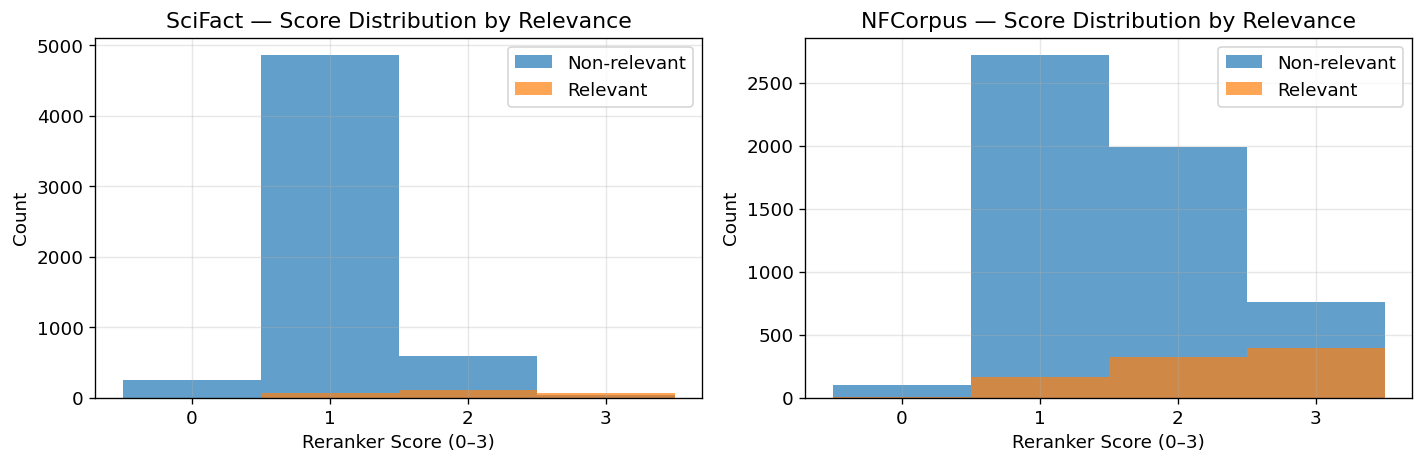

Saved.


In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (scores_df, name) in zip(axes, [(scifact_scores_df, "SciFact"), (nfcorpus_scores_df, "NFCorpus")]):
    pairs = pd.read_parquet(f"data/interim/{name.lower()}/query_doc_pairs.parquet")
    merged = scores_df.merge(pairs[["query_id", "doc_id", "is_relevant"]], on=["query_id", "doc_id"])
    for label, grp in merged.groupby("is_relevant"):
        ax.hist(grp["reranker_score"], bins=[-.5, .5, 1.5, 2.5, 3.5], alpha=0.7,
                label=f"{'Relevant' if label else 'Non-relevant'}")
    ax.set_xlabel("Reranker Score (0–3)")
    ax.set_ylabel("Count")
    ax.set_xticks([0, 1, 2, 3])
    ax.set_title(f"{name} — Score Distribution by Relevance")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
Path("outputs/midproject/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("outputs/midproject/figures/reranker_score_distribution.png", bbox_inches="tight")
plt.show()
print("Saved.")

## 4  Expected score distribution (continuous)

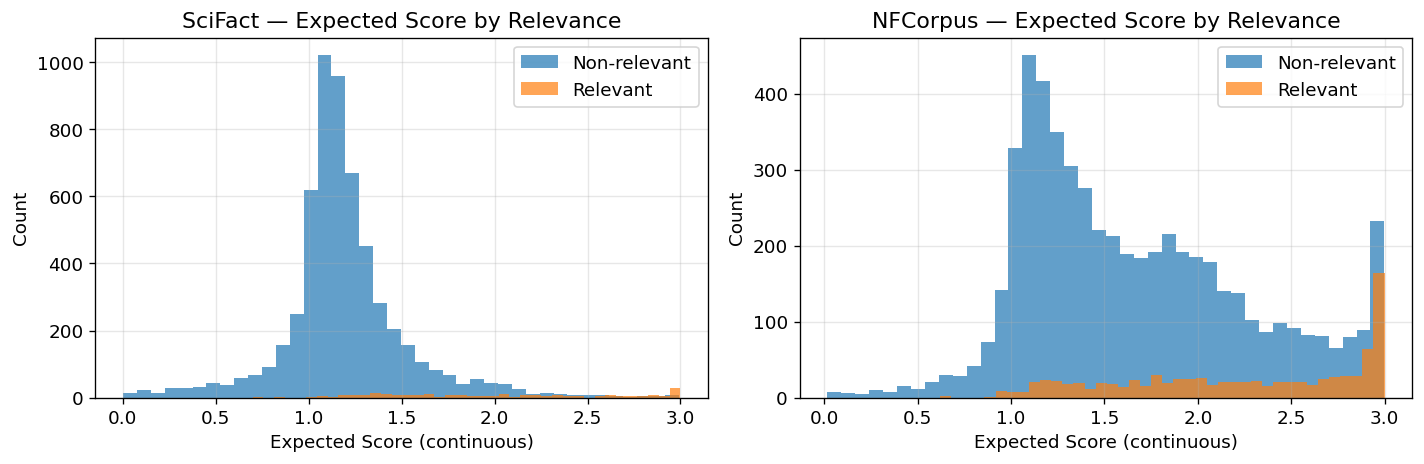

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (scores_df, name) in zip(axes, [(scifact_scores_df, "SciFact"), (nfcorpus_scores_df, "NFCorpus")]):
    pairs = pd.read_parquet(f"data/interim/{name.lower()}/query_doc_pairs.parquet")
    merged = scores_df.merge(pairs[["query_id", "doc_id", "is_relevant"]], on=["query_id", "doc_id"])
    for label, grp in merged.groupby("is_relevant"):
        ax.hist(grp["reranker_expected_score"], bins=40, alpha=0.7,
                label=f"{'Relevant' if label else 'Non-relevant'}")
    ax.set_xlabel("Expected Score (continuous)")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} — Expected Score by Relevance")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/midproject/figures/reranker_expected_score_distribution.png", bbox_inches="tight")
plt.show()

## 5  Probability distribution per score class (SciFact)

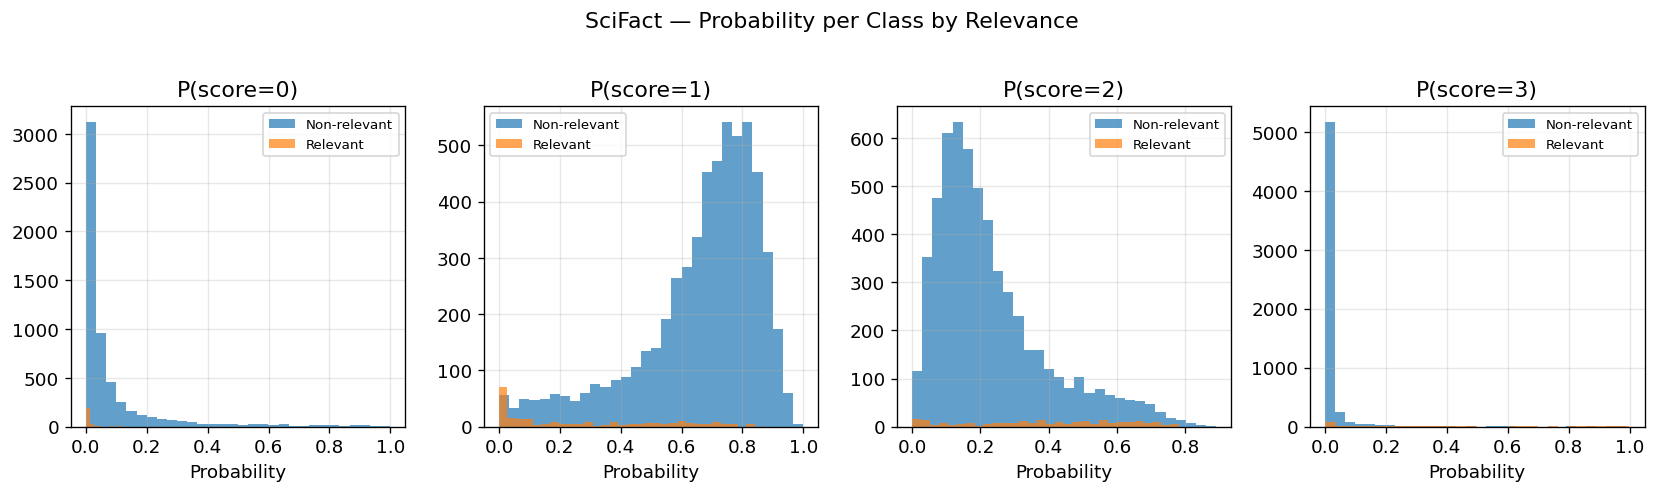

In [10]:
import numpy as np

pairs = pd.read_parquet("data/interim/scifact/query_doc_pairs.parquet")
merged = scifact_scores_df.merge(pairs[["query_id", "doc_id", "is_relevant"]], on=["query_id", "doc_id"])

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for k, ax in enumerate(axes):
    for label, grp in merged.groupby("is_relevant"):
        ax.hist(grp[f"prob_{k}"], bins=30, alpha=0.7,
                label=f"{'Relevant' if label else 'Non-relevant'}")
    ax.set_title(f"P(score={k})")
    ax.set_xlabel("Probability")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("SciFact — Probability per Class by Relevance", y=1.02)
plt.tight_layout()
plt.savefig("outputs/midproject/figures/reranker_prob_by_class.png", bbox_inches="tight")
plt.show()

In [11]:
print("Shape:", scifact_scores_df.shape)
print("Columns:", list(scifact_scores_df.columns))
print("\nScore value counts:")
print(scifact_scores_df["reranker_score"].value_counts().sort_index())
scifact_scores_df.head(10)

Shape: (6000, 9)
Columns: ['query_id', 'doc_id', 'reranker_score', 'reranker_expected_score', 'prob_0', 'prob_1', 'prob_2', 'prob_3', 'reranker_rank']

Score value counts:
reranker_score
0     256
1    4934
2     694
3     116
Name: count, dtype: int64


,query_id,doc_id,reranker_score,reranker_expected_score,prob_0,prob_1,prob_2,prob_3,reranker_rank
0,1,825728,1,1.136117,0.018634,0.830564,0.146852,0.003950,17
1,1,10931595,1,1.363279,0.028909,0.601580,0.346833,0.022677,3
2,1,43385013,1,1.277416,0.010255,0.707680,0.276457,0.005607,9
3,1,13231899,1,1.176615,0.022600,0.786227,0.183131,0.008042,15
4,1,18953920,1,1.270374,0.007492,0.722337,0.262475,0.007696,10
5,1,17388232,1,1.224887,0.009570,0.759777,0.226849,0.003804,12
6,1,45638119,1,1.302206,0.003089,0.699617,0.289293,0.008001,8
7,1,24998637,2,1.657821,0.009434,0.406773,0.500328,0.083464,1
8,1,17518195,1,1.190272,0.010761,0.792463,0.192520,0.004256,14
9,1,25298276,1,1.255251,0.010458,0.731965,0.249446,0.008132,11
